# Customer Segmentation & Churn Pattern Analytics in European Banking

## Objective
To analyze customer churn behavior using segmentation techniques and identify high-risk customer groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Data Ingestion
Loading dataset and performing initial inspection.

In [2]:
df = pd.read_csv("C:/Users/ektap/Downloads/European_Bank.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Data Cleaning & Preparation
Removing irrelevant columns and preparing dataset.

In [3]:
df = df.drop(columns=["Surname", "CustomerId"])

df.drop_duplicates(inplace=True)

df["Geography"] = df["Geography"].astype("category")
df["Gender"] = df["Gender"].astype("category")

## Feature Engineering
Creating segmentation variables such as age group, credit band, etc.

In [4]:
df["AgeGroup"] = pd.cut(df["Age"],
                       bins=[0,30,45,60,100],
                       labels=["<30","30-45","46-60","60+"])

In [5]:
def credit_band(x):
    if x < 500:
        return "Low"
    elif x < 700:
        return "Medium"
    else:
        return "High"

df["CreditBand"] = df["CreditScore"].apply(credit_band)

In [6]:
def tenure_group(x):
    if x <= 2:
        return "New"
    elif x <= 6:
        return "Mid-term"
    else:
        return "Long-term"

df["TenureGroup"] = df["Tenure"].apply(tenure_group)

In [7]:
def balance_group(x):
    if x == 0:
        return "Zero"
    elif x < 100000:
        return "Low"
    else:
        return "High"

df["BalanceGroup"] = df["Balance"].apply(balance_group)

## Exploratory Data Analysis (EDA)
Analyzing churn across different segments.

In [8]:
churn_rate = df["Exited"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


C:\Users\ektap\AppData\Local\Temp\ipykernel_20868\2164306836.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  geo_churn = df.groupby("Geography")["Exited"].mean() * 100


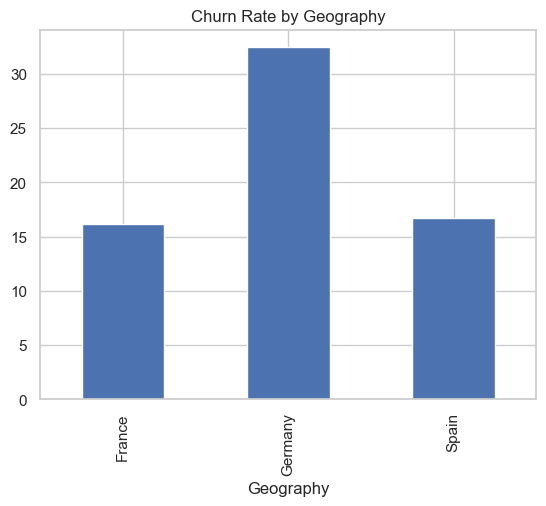

In [9]:
geo_churn = df.groupby("Geography")["Exited"].mean() * 100
geo_churn.plot(kind="bar", title="Churn Rate by Geography")
plt.show()

C:\Users\ektap\AppData\Local\Temp\ipykernel_20868\721566788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby("AgeGroup")["Exited"].mean() * 100


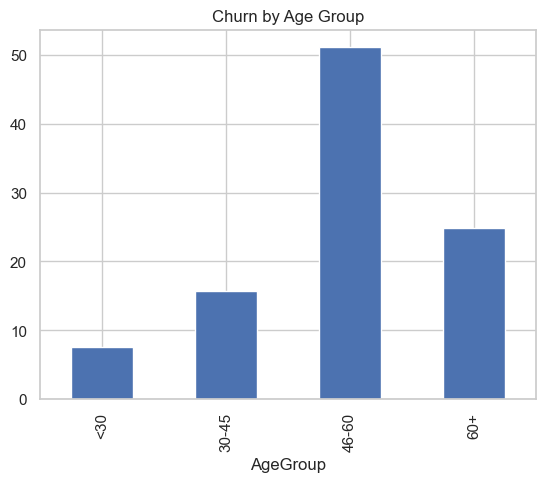

In [10]:
age_churn = df.groupby("AgeGroup")["Exited"].mean() * 100
age_churn.plot(kind="bar", title="Churn by Age Group")
plt.show()

C:\Users\ektap\AppData\Local\Temp\ipykernel_20868\721566788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn = df.groupby("AgeGroup")["Exited"].mean() * 100


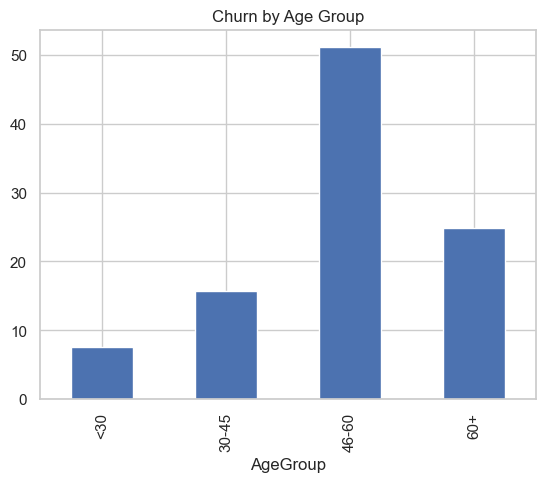

In [11]:
age_churn = df.groupby("AgeGroup")["Exited"].mean() * 100
age_churn.plot(kind="bar", title="Churn by Age Group")
plt.show()

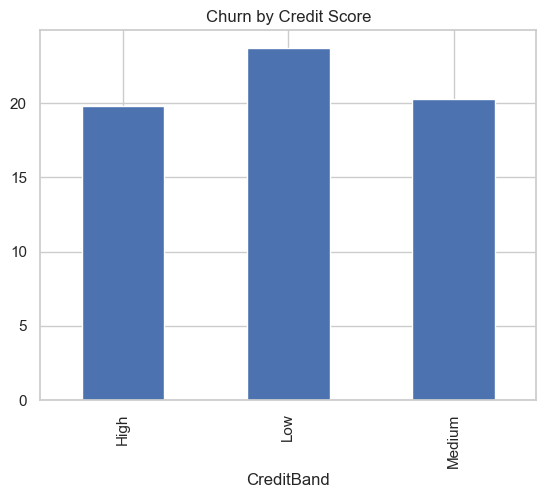

In [12]:
credit_churn = df.groupby("CreditBand")["Exited"].mean() * 100
credit_churn.plot(kind="bar", title="Churn by Credit Score")
plt.show()

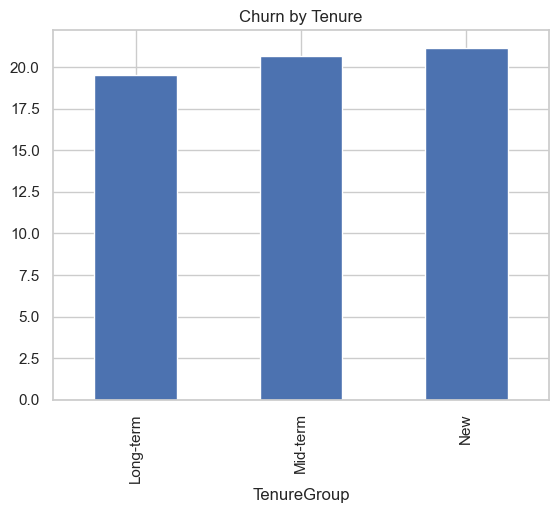

In [13]:
tenure_churn = df.groupby("TenureGroup")["Exited"].mean() * 100
tenure_churn.plot(kind="bar", title="Churn by Tenure")
plt.show()

C:\Users\ektap\AppData\Local\Temp\ipykernel_20868\3538326699.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_churn = df.groupby("Gender")["Exited"].mean() * 100


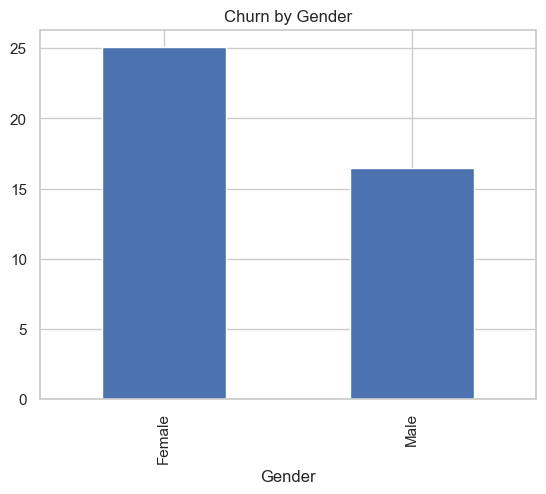

In [14]:
gender_churn = df.groupby("Gender")["Exited"].mean() * 100
gender_churn.plot(kind="bar", title="Churn by Gender")
plt.show()

In [15]:
high_value = df[df["Balance"] > 100000]

high_value_churn = high_value["Exited"].mean() * 100
print(f"High Value Customer Churn Rate: {high_value_churn:.2f}%")


High Value Customer Churn Rate: 25.23%


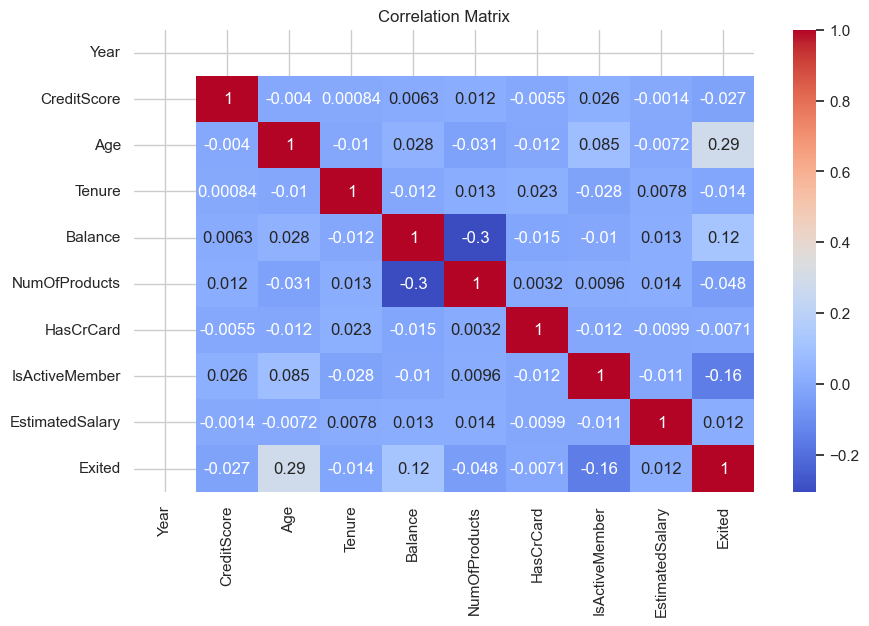

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

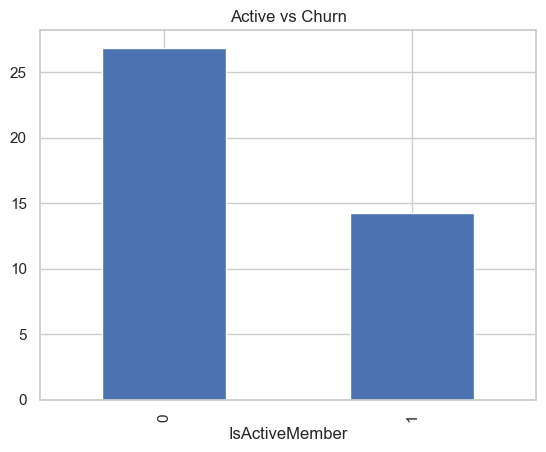

In [17]:
active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100
active_churn.plot(kind="bar", title="Active vs Churn")
plt.show()

## Key Performance Indicators
Calculating important churn metrics.

In [18]:
kpi = {
    "Overall Churn Rate": churn_rate,
    "High Value Churn Rate": high_value_churn,
    "Inactive Churn Rate": df[df["IsActiveMember"]==0]["Exited"].mean()*100
}

for k, v in kpi.items():
    print(f"{k}: {v:.2f}%")

Overall Churn Rate: 20.37%
High Value Churn Rate: 25.23%
Inactive Churn Rate: 26.85%


In [19]:
import streamlit as st
import pandas as pd

df = pd.read_csv("C:/Users/ektap/Downloads/European_Bank.csv")

st.title("Customer Churn Dashboard")

st.metric("Overall Churn Rate", f"{df['Exited'].mean()*100:.2f}%")

geo = st.selectbox("Select Geography", df["Geography"].unique())

filtered = df[df["Geography"] == geo]

st.write(filtered.groupby("Age")["Exited"].mean())

2026-04-30 12:17:35.448 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 12:17:36.290 
  command:

    streamlit run C:\Users\ektap\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-30 12:17:36.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 12:17:36.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 12:17:36.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 12:17:36.295 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 12:17:36.296 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-30 12:17:36.299 Thread 'MainThread': mi